In [75]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt 

import portfolio
import market_data
import models
import simulation
import risk_measure

# import arch

import importlib

my_modules = [portfolio, market_data, models, simulation, risk_measure]

for module in  my_modules:
    importlib.reload(module)


[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

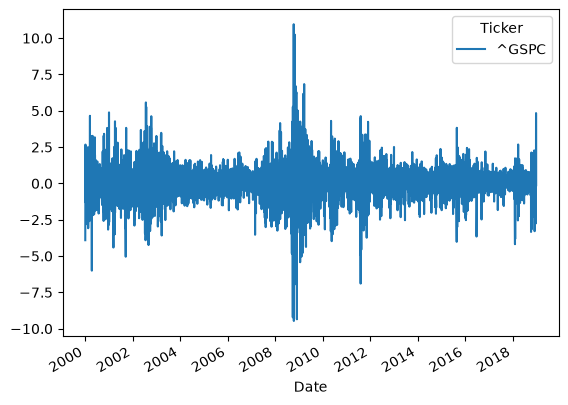

In [56]:
port = portfolio.Portfolio(
    holdings={
        "^GSPC": 1,
    }
)

data = market_data.MarketData.from_yfinance(
    port.assets,
    "2000-01-01",
    "2018-12-31",
)

risk_factors = port.risk_factors(data)
risk_factors.plot()

Date
2000-01-04         NaN
2000-01-05         NaN
2000-01-06         NaN
2000-01-07         NaN
2000-01-10         NaN
                ...   
2018-12-21    1.757712
2018-12-24    1.860511
2018-12-26    2.088296
2018-12-27    2.941911
2018-12-28    2.853313
Name: ^GSPC, Length: 4777, dtype: float64


<Axes: xlabel='Date'>

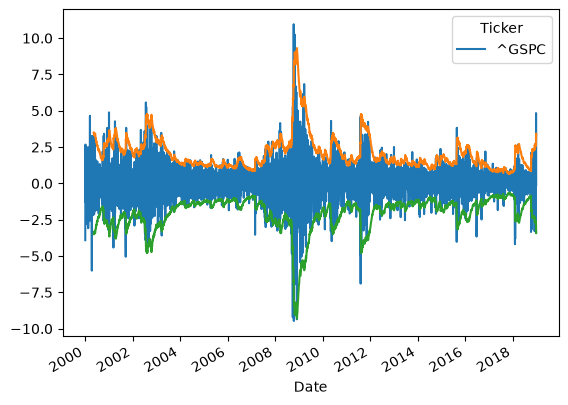

In [63]:
ewma = models.univariate_ewma_variance_estimator(
    risk_factors
)

print(ewma.variances)
risk_factors.plot()
(2*np.sqrt(ewma.variances)).plot()
(-2*np.sqrt(ewma.variances)).plot()

In [59]:
garch1_1 = models.fit_garch(risk_factors)
print("GARCH(1,1) model:", "\n", garch1_1.summary(), "\n")

GARCH(1,1) model: 
                        Zero Mean - GARCH Model Results                        
Dep. Variable:                  ^GSPC   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6548.37
Distribution:                  Normal   AIC:                           13102.7
Method:            Maximum Likelihood   BIC:                           13122.2
                                        No. Observations:                 4777
Date:                Thu, Sep 17 2026   Df Residuals:                     4777
Time:                        11:46:50   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0181  4.763e-03      

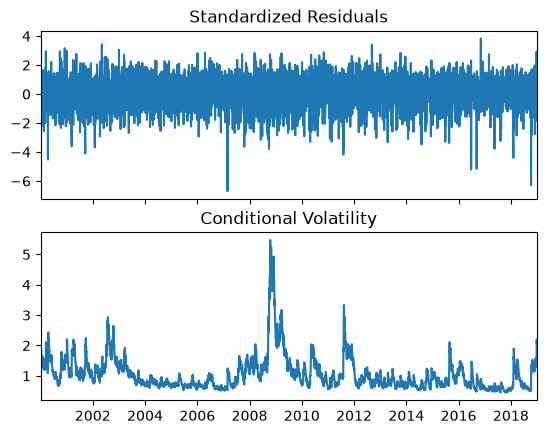

In [62]:
garch1_1.plot()
plt.show()
plt.close()

<Axes: xlabel='Date'>

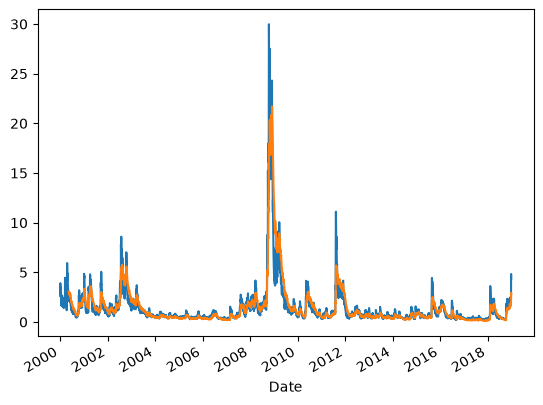

In [73]:
garch1_1_cond_var = (models.garch_conditional_variance(garch1_1).variances)
garch1_1_cond_var.plot()
(ewma.variances).plot()

In [72]:
models.garch_forecast(garch1_1)

,h.1
Date,
2018-12-28,3.872283


0.01   -2.326348
0.05   -1.644854
Name: quantile, dtype: float64


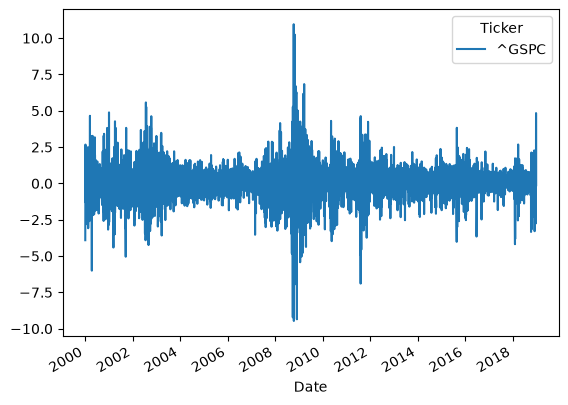

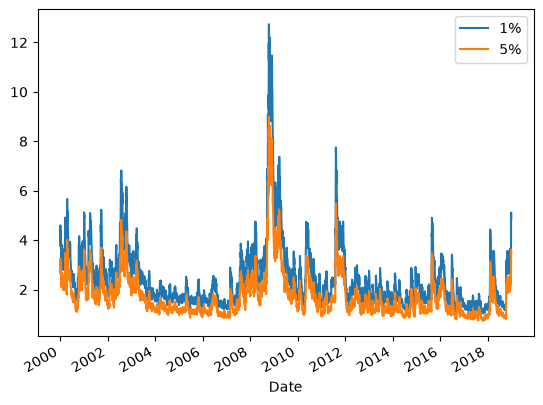

In [78]:
q = simulation.parametric_quantiles(garch1_1,[0.01,0.05])
print(q)
VaR = risk_measure.parametric_value_at_risk(garch1_1_cond_var,q)
risk_factors.plot()
VaR.plot()
plt.show()